## User study analysis

# Participant background

In [2]:
import pandas as pd

# Load your dataset
df = pd.read_excel("Integrated_Responses.xlsx")  # <-- change filename accordingly

# EXACT or NEAR-EXACT substrings from your questionnaire items
patterns = {
    "semantic_web_familiarity": "semantic web (e.g., rdf, sparql, fair",
    "metadata_standards_familiarity": "metadata standards (e.g., dublin core",
    "turtle_syntax_familiarity": "turtle syntax",
    "data_modeling_familiarity": "data modeling (e.g., designing database schemas",
    "structured_data_familiarity": "working with structured data (e.g., tabular data",
    "years_experience_semweb": "how many years of experience do you have in semantic web"
}

# Function to match cleaned column names
def find_column(pattern):
    for col in df.columns:
        col_clean = col.lower().replace("\n", " ").replace("\xa0", " ")
        if pattern in col_clean:
            return col
    return None

matched_columns = {key: find_column(pat.lower()) for key, pat in patterns.items()}

print("\nMatched background columns:")
for key, col in matched_columns.items():
    print(f"{key} -> {col}")

# ---- Use participant ID FROM the Excel column (not generated) ----
participant_id_col = find_column("please enter your participant id")

if participant_id_col is None:
    raise ValueError(
        "Participant ID column not found. "
        "Expected something like: 'Please enter your participant ID below (sent to you via email).' "
        "Tip: print(df.columns.tolist()) to inspect exact column headers."
    )

# Rename the found column to a simple name
df = df.rename(columns={participant_id_col: "participant_id"})

# Optional: clean participant_id values (strip spaces; keep blanks as NaN)
df["participant_id"] = df["participant_id"].astype(str).str.strip()
df.loc[df["participant_id"].isin(["", "nan", "None"]), "participant_id"] = pd.NA

# Extract the matched columns
selected_cols = ["participant_id"] + [col for col in matched_columns.values() if col]

background_df = df[selected_cols]

# Save output
background_df.to_csv("participants_background_id_corrected.csv", index=False)



Matched background columns:
semantic_web_familiarity -> Please rate your level of familiarity with each of the following concepts..Semantic Web (e.g., RDF, SPARQL, FAIR)
metadata_standards_familiarity -> Please rate your level of familiarity with each of the following concepts..Metadata standards (e.g., Dublin Core, schema.org)
turtle_syntax_familiarity -> Please rate your level of familiarity with each of the following concepts..Turtle syntax
data_modeling_familiarity -> Please rate your level of familiarity with each of the following concepts..Data modeling (e.g., designing database schemas, JSON, XML, or ontologies)
structured_data_familiarity -> Please rate your level of familiarity with each of the following concepts..Working with structured data (e.g., tabular data, or converting unstructured data to structured data)
years_experience_semweb -> How many years of experience do you have in Semantic Web technologies?

Saved: participants_background_corrected.csv


In [3]:
import pandas as pd
import numpy as np
import re

# ---------------------------------------------------------
# 1. Load your ORIGINAL background file (qualitative text)
# ---------------------------------------------------------
df = pd.read_csv("participants_background_id_corrected.csv")

# Identify columns to score (all except participant_id)
cols = [c for c in df.columns if c != "participant_id"]

# ---------------------------------------------------------
# 2. Clean & normalize text
# ---------------------------------------------------------

def clean_text(x):
    """Normalize all qualitative answers for safe matching."""
    if pd.isna(x):
        return ""
    x = str(x).strip().lower()
    x = x.replace("–", "-")  # normalize special dash
    x = re.sub(r"[^a-z0-9\s\-]", "", x)  # remove punctuation
    x = re.sub(r"\s+", " ", x)  # collapse multiple spaces
    return x

df_clean = df.copy()
for col in cols:
    df_clean[col] = df_clean[col].apply(clean_text)

# ---------------------------------------------------------
# 3. Mapping functions
# ---------------------------------------------------------

# Familiarity mapping (5 items)
fam_map = {
    "not at all familiar": 1,
    "slightly familiar": 2,
    "moderately familiar": 3,
    "very familiar": 4,
    "extremely familiar": 5
}

# Experience mapping (1 item)
def map_experience(x):
    if "none" in x:
        return 1
    if "less than one" in x:
        return 2
    if "1-3 years" in x or "1 3 years" in x:
        return 3
    if "more than 3" in x:
        return 4
    return np.nan  # should not occur if data is correct

def map_familiarity(x):
    for key, val in fam_map.items():
        if key in x:
            return val
    return np.nan   # should not occur if data is correct

# ---------------------------------------------------------
# 4. Apply mapping
# ---------------------------------------------------------

df_scored = df_clean.copy()

# The first 5 cols = familiarity items
for col in cols[:-1]:
    df_scored[col] = df_clean[col].apply(map_familiarity)

# Last col = experience
experience_col = cols[-1]
df_scored[experience_col] = df_clean[experience_col].apply(map_experience)

# ---------------------------------------------------------
# 5. Compute the composite mean familiarity score
# ---------------------------------------------------------

df_scored["familiarity_score"] = df_scored[cols].astype(float).mean(axis=1)

# ---------------------------------------------------------
# 6. Save the scored file
# ---------------------------------------------------------

df_scored.to_csv("participants_background_scored_corrected.csv", index=False)

print("Saved: participants_background_scored_corrected.csv")
print(df_scored.head())


Saved: participants_background_scored_corrected.csv
  participant_id  \
0            P01   
1            P13   
2            P12   
3            P11   
4            P04   

   Please rate your level of familiarity with each of the following concepts..Semantic Web (e.g., RDF, SPARQL, FAIR)  \
0                                                  1                                                                   
1                                                  5                                                                   
2                                                  5                                                                   
3                                                  2                                                                   
4                                                  1                                                                   

   Please rate your level of familiarity with each of the following concepts..Metadata standards (e.g., Du

----- Distribution Summary -----
Mean = 2.71
SD = 1.25
Skew = 0.56 (Slightly right-skewed)
Shapiro–Wilk: W = 0.905, p = 0.1853
No strong evidence against normality
--------------------------------


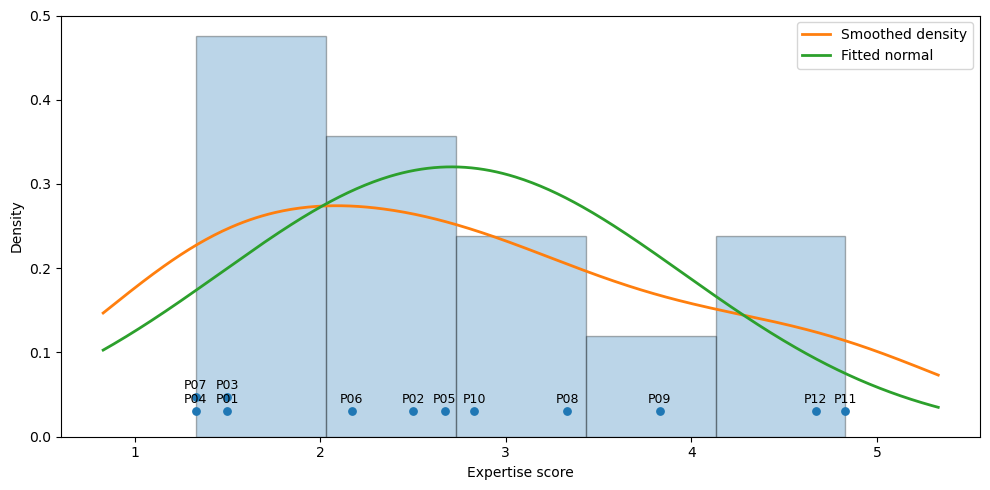

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from collections import defaultdict

participants = ["P01","P02","P03","P04","P05","P06","P07","P08","P09","P10","P11","P12"]
scores = np.array([1.50, 2.50, 1.50, 1.33, 2.67, 2.17, 1.33, 3.33, 3.83, 2.83, 4.83, 4.67])

# ---- statistics ----
mean = scores.mean()
sd = scores.std(ddof=1)
skew = stats.skew(scores, bias=False)
W, p = stats.shapiro(scores)

# ---- automatic interpretation ----
if skew > 0.5:
    skew_text = "Slightly right-skewed"
elif skew < -0.5:
    skew_text = "Slightly left-skewed"
else:
    skew_text = "Approximately symmetric"

if p < 0.05:
    normality_text = "Strong evidence against normality"
else:
    normality_text = "No strong evidence against normality"

print("----- Distribution Summary -----")
print(f"Mean = {mean:.2f}")
print(f"SD = {sd:.2f}")
print(f"Skew = {skew:.2f} ({skew_text})")
print(f"Shapiro–Wilk: W = {W:.3f}, p = {p:.4f}")
print(normality_text)
print("--------------------------------")

# ---- plot ----
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(scores, bins="auto", density=True, alpha=0.30, edgecolor="black")

x = np.linspace(scores.min() - 0.5, scores.max() + 0.5, 400)
kde = stats.gaussian_kde(scores)
ax.plot(x, kde(x), linewidth=2, label="Smoothed density")
ax.plot(x, stats.norm.pdf(x, loc=mean, scale=sd), linewidth=2, label="Fitted normal")

# ---- participant points (stack duplicates) ----
ymin, ymax = ax.get_ylim()
base_y = ymin + 0.06 * (ymax - ymin)
step_y = 0.035 * (ymax - ymin)
label_dy = 0.012 * (ymax - ymin)

groups = defaultdict(list)
for i, s in enumerate(scores):
    groups[round(float(s), 2)].append(i)

x_pts = scores.copy()
y_pts = np.zeros_like(scores, dtype=float)

for key, idxs in groups.items():
    for j, i in enumerate(sorted(idxs)):
        y_pts[i] = base_y + j * step_y

ax.scatter(x_pts, y_pts, s=28)

for pid, s, y in zip(participants, x_pts, y_pts):
    ax.text(s, y + label_dy, pid, ha="center", va="bottom", fontsize=9)

# ax.set_title("Expertise score distribution")
ax.set_xlabel("Expertise score")
ax.set_ylabel("Density")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

# Post-task Questionnaires: SUS and TAM Results

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib as mpl
import pandas as pd
import numpy as np
import re

# ======================================================
# 1. LOAD DATA
# ======================================================
df = pd.read_excel("Integrated_Responses.xlsx")

# ======================================================
# 2. TOOL NAMES (UPDATED)
# ======================================================
TOOLS = ["Standard Form", "AI-assisted Form", "Turtle Editor"]

# Map NEW names → OLD names found in Excel column headers
TOOL_ALIASES = {
    "Standard Form": "Form Interface",
    "AI-assisted Form": "LLM-Assisted Form",
    "Turtle Editor": "Turtle Editor"
}

# ======================================================
# 3. TAM ITEMS (INCLUDING REVERSE-CODED ITEMS)
# ======================================================

# Perceived Usefulness (PU)
pu_items = [
    "This tool enables me to accomplish metadata curation tasks",
    "This tool supports critical aspects of my metadata curation work",
    "Using this tool improves the quality of the metadata I curate",
    "Using this tool increases my productivity on curating metadata",
]
pu_reverse = [
    "This tool does not support critical aspects of my metadata curation work"
]

# Perceived Ease of Use (PEU)
peu_items = [
    "This tool provides helpful guidance in performing tasks",
    "Interacting with this tool does not require a lot of my mental effort",
    "I find it easy to get this tool to do what I want it to do",
]
peu_reverse = [
    "Interacting with this tool is frustrating"
]

# Intention to Use (PI)
pi_items = [
    "I plan to use this tool again for future Knowledge Graph metadata curation",
    "I would recommend this tool to others who work with metadata",
]
pi_reverse = [
    "I do not intend to use this tool again for future Knowledge Graph metadata curation"
]

# SUS QUESTIONS
sus_base = [
    "I think that I would like to use this system frequently",
    "I found the system unnecessarily complex",
    "I thought the system was easy to use",
    "I think that I would need the support of a technical person to be able to use this system",
    "I found the various functions in this system were well integrated",
    "I thought there was too much inconsistency in this system",
    "I would imagine that most people would learn to use this system very quickly",
    "I found the system very awkward to use",
    "I felt very confident using the system",
    "I needed to learn a lot of things before I could get going with this system",
]

# ======================================================
# 4. HELPER FUNCTIONS
# ======================================================

def clean_text(s):
    return re.sub(r"\s+", " ", str(s)).replace("\xa0", " ").strip()

def map_likert(series):
    mapping = {
        "strongly disagree": 1, "disagree": 2, "neutral": 3,
        "agree": 4, "strongly agree": 5
    }
    return (
        series.astype(str)
        .str.lower()
        .str.strip()
        .replace({r"[^a-z ]": ""}, regex=True)
        .map(mapping)
    )

def reverse_score(series):
    return series.apply(lambda x: 6 - x if pd.notna(x) else np.nan)

def compute_sus(row):
    vals = [v for v in row if pd.notna(v)]
    if len(vals) < 10:
        return np.nan
    scores = []
    for i, val in enumerate(vals):
        if (i + 1) % 2 == 1:
            scores.append(val - 1)
        else:
            scores.append(5 - val)
    return sum(scores) * 2.5

def find_columns(base_items, tool):
    """Match a tool name + item text in column headers."""
    found = []
    true_name = TOOL_ALIASES[tool]   # <-- USE ALIAS HERE
    for q in base_items:
        for c in df.columns:
            cname = clean_text(c)
            if true_name.lower() in cname.lower() and q.lower() in cname.lower():
                found.append(c)
                break
    return found

def mean_block(df, items, tool, reverse_items):
    cols = find_columns(items + reverse_items, tool)
    if not cols:
        return pd.Series(np.nan, index=df.index)

    sub = df[cols].apply(map_likert, axis=0)

    for rev_item in reverse_items:
        for c in cols:
            if rev_item.lower() in clean_text(c).lower():
                sub[c] = reverse_score(sub[c])

    return sub.mean(axis=1)

# ======================================================
# 5. COMPUTE SCORES
# ======================================================
results = []

for tool in TOOLS:
    sus_cols = find_columns(sus_base, tool)
    sus_numeric = df[sus_cols].apply(map_likert, axis=0)
    sus_scores = sus_numeric.apply(compute_sus, axis=1)

    temp = pd.DataFrame({
        "ParticipantID": df["Please enter your participant ID below (sent to you via email)."],
        "Tool": tool,
        "SUS": sus_scores,
        "PU": mean_block(df, pu_items, tool, pu_reverse),
        "PEU": mean_block(df, peu_items, tool, peu_reverse),
        "PI": mean_block(df, pi_items, tool, pi_reverse),
    })
    results.append(temp)

final_scores = pd.concat(results, ignore_index=True)

summary = final_scores.groupby("Tool")[["SUS", "PU", "PEU", "PI"]].agg(["mean", "std"])

print(summary.round(2))



                    SUS           PU         PEU          PI      
                   mean    std  mean   std  mean   std  mean   std
Tool                                                              
AI-assisted Form  80.62  14.27  4.13  0.71  4.17  0.55  4.31  0.92
Standard Form     63.96  20.24  3.92  0.46  3.52  0.69  3.44  0.95
Turtle Editor     32.71  24.18  2.05  0.99  1.75  0.77  1.81  0.92


In [14]:
import pingouin as pg

metrics = ["SUS", "PU", "PEU", "PI"]

for m in metrics:
    aov = pg.rm_anova(
        data=final_scores,
        dv=m,
        within="Tool",
        subject="ParticipantID",
        detailed=True
    )
    print("\n=== RM-ANOVA for", m, "===\n")
    print(aov)


=== RM-ANOVA for SUS ===

  Source            SS  DF           MS          F         p-unc       ng2  \
0   Tool  14201.388889   2  7100.694444  34.093665  1.819905e-07  0.518736   
1  Error   4581.944444  22   208.270202        NaN           NaN       NaN   

        eps  
0  0.780176  
1       NaN  

=== RM-ANOVA for PU ===

  Source         SS  DF         MS          F         p-unc  p-GG-corr  \
0   Tool  31.486667   2  15.743333  45.532866  1.513591e-08   0.000002   
1  Error   7.606667  22   0.345758        NaN           NaN        NaN   

        ng2       eps sphericity   W-spher   p-spher  
0  0.628226  0.673497      False  0.515211  0.036302  
1       NaN       NaN        NaN       NaN       NaN  

=== RM-ANOVA for PEU ===

  Source         SS  DF         MS          F         p-unc       ng2  \
0   Tool  37.572917   2  18.786458  60.513981  1.140300e-09  0.713339   
1  Error   6.829861  22   0.310448        NaN           NaN       NaN   

        eps  
0  0.743382  
1      

In [15]:
import pingouin as pg
import pandas as pd

metrics = ["SUS", "PU", "PEU", "PI"]

all_posthoc = []

for m in metrics:
    ph = pg.pairwise_tests(
        data=final_scores,
        dv=m,
        within="Tool",
        subject="ParticipantID",
        padjust="holm",
        effsize="cohen"
    )
    
    # Keep only the columns we need
    ph = ph[["A", "B", "T", "dof", "p-corr", "cohen"]].copy()
    ph["Metric"] = m
    
    all_posthoc.append(ph)

posthoc_df = pd.concat(all_posthoc, ignore_index=True)

# Reorder columns
posthoc_df = posthoc_df[["Metric", "A", "B", "T", "dof", "p-corr", "cohen"]]

print(posthoc_df.round(4))

   Metric                 A              B       T   dof  p-corr   cohen
0     SUS  AI-assisted Form  Standard Form  3.6487  11.0  0.0038  0.9519
1     SUS  AI-assisted Form  Turtle Editor  6.6345  11.0  0.0001  2.4138
2     SUS     Standard Form  Turtle Editor  5.6029  11.0  0.0003  1.4016
3      PU  AI-assisted Form  Standard Form  1.6215  11.0  0.1332  0.3615
4      PU  AI-assisted Form  Turtle Editor  7.2711  11.0  0.0000  2.4221
5      PU     Standard Form  Turtle Editor  6.9122  11.0  0.0001  2.4203
6     PEU  AI-assisted Form  Standard Form  4.1870  11.0  0.0015  1.0330
7     PEU  AI-assisted Form  Turtle Editor  8.7620  11.0  0.0000  3.6224
8     PEU     Standard Form  Turtle Editor  7.5264  11.0  0.0000  2.4172
9      PI  AI-assisted Form  Standard Form  3.1476  11.0  0.0093  0.9250
10     PI  AI-assisted Form  Turtle Editor  7.1071  11.0  0.0001  2.7317
11     PI     Standard Form  Turtle Editor  5.8602  11.0  0.0002  1.7605


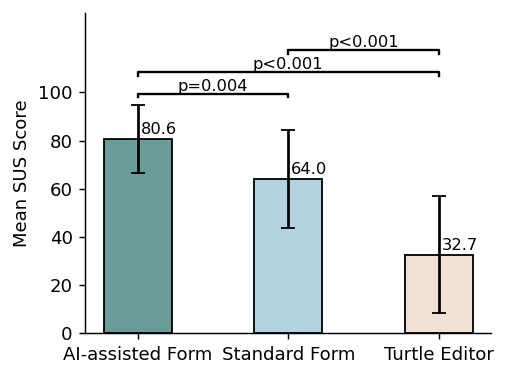

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# -----------------------------
# Helpers
# -----------------------------
def add_sig_bracket(ax, x1, x2, y, h, text, fontsize=9):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.3, c="black")
    ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom", fontsize=fontsize)

def get_p(posthoc_df, metric, A, B):
    sub = posthoc_df[posthoc_df["Metric"] == metric]
    row = sub[((sub["A"] == A) & (sub["B"] == B)) | ((sub["A"] == B) & (sub["B"] == A))]
    if row.empty:
        return None
    return float(row.iloc[0]["p-corr"])

def fmt_p(p):
    if p is None:
        return "p=?"
    return "p<0.001" if p < 0.001 else f"p={p:.3f}"

# -----------------------------
# SUS plot
# -----------------------------
tools = list(summary.index)                         # order used in summary
means = summary[("SUS", "mean")].reindex(tools)
errors = summary[("SUS", "std")].reindex(tools)

x = np.arange(len(tools))

# (Optional) choose your colors here
colors = ['#6a9d9a', '#b1d4e0', '#f0e0d6']  # Standard, AI-assisted, Turtle

fig, ax = plt.subplots(figsize=(4, 3))

bars = ax.bar(
    x, means.values, yerr=errors.values,
    capsize=4, width=0.45, color=colors, edgecolor="black"
)

ax.set_ylabel("Mean SUS Score")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f'))
ax.set_xticks(x)
ax.set_xticklabels(tools, rotation=0)

# Values on bars
for i, bar in enumerate(bars):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2 + 0.14, h + 2, f"{h:.1f}", ha="center", fontsize=9)

# -----------------------------
# Add p-value brackets (choose the comparisons you want)
# -----------------------------
pairs = [
    ("AI-assisted Form", "Standard Form"),
    ("AI-assisted Form", "Turtle Editor"),
    ("Standard Form", "Turtle Editor"),
]

tool_to_x = {t: i for i, t in enumerate(tools)}

# start above the tallest error bar
y_base = float((means + errors).max()) + 3
step = 9 # vertical spacing between stacked brackets

for i, (A, B) in enumerate(pairs):
    p = get_p(posthoc_df, "SUS", A, B)
    if p is None:
        continue
    x1, x2 = tool_to_x[A], tool_to_x[B]
    add_sig_bracket(ax, x1, x2, y=y_base + i*step, h=1.5, text=fmt_p(p), fontsize=9)

# ensure brackets fit
ax.set_ylim(0, max(100, y_base + len(pairs)*step + 8))
ax.set_yticks(np.arange(0, 101, 20))
plt.tight_layout()
plt.savefig("sus_with_pvalues.png", dpi=300)
plt.show()

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Same tool colors as your SUS
tool_colors = ['#6a9d9a', '#b1d4e0', '#f0e0d6']  # Standard, AI-assisted, Turtle

def get_p(posthoc_df, metric, A, B):
    """Fetch Holm-corrected p-value for a pair (A,B), regardless of order."""
    sub = posthoc_df[posthoc_df["Metric"] == metric]
    row = sub[((sub["A"] == A) & (sub["B"] == B)) | ((sub["A"] == B) & (sub["B"] == A))]
    if row.empty:
        return None
    return float(row.iloc[0]["p-corr"])

def fmt_p(p):
    if p is None:
        return "p=?"
    return "p<0.001" if p < 0.001 else f"p={p:.3f}"

def make_p_text(posthoc_df, metric):
    """Create the textbox string in the order you want."""
    pairs = [
        ("AI-assisted Form", "Standard Form", "AI vs Std"),
        ("AI-assisted Form", "Turtle Editor", "AI vs Turtle"),
        ("Standard Form", "Turtle Editor", "Std vs Turtle"),
    ]
    lines = []
    for A, B, label in pairs:
        p = get_p(posthoc_df, metric, A, B)
        lines.append(f"{label}: {fmt_p(p)}")
    return "\n".join(lines)

def add_p_box(ax, text):
    """Add a small note box to the right of the plot area."""
    ax.text(
        1.02, 0.98, text,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", linewidth=0.8)
    )

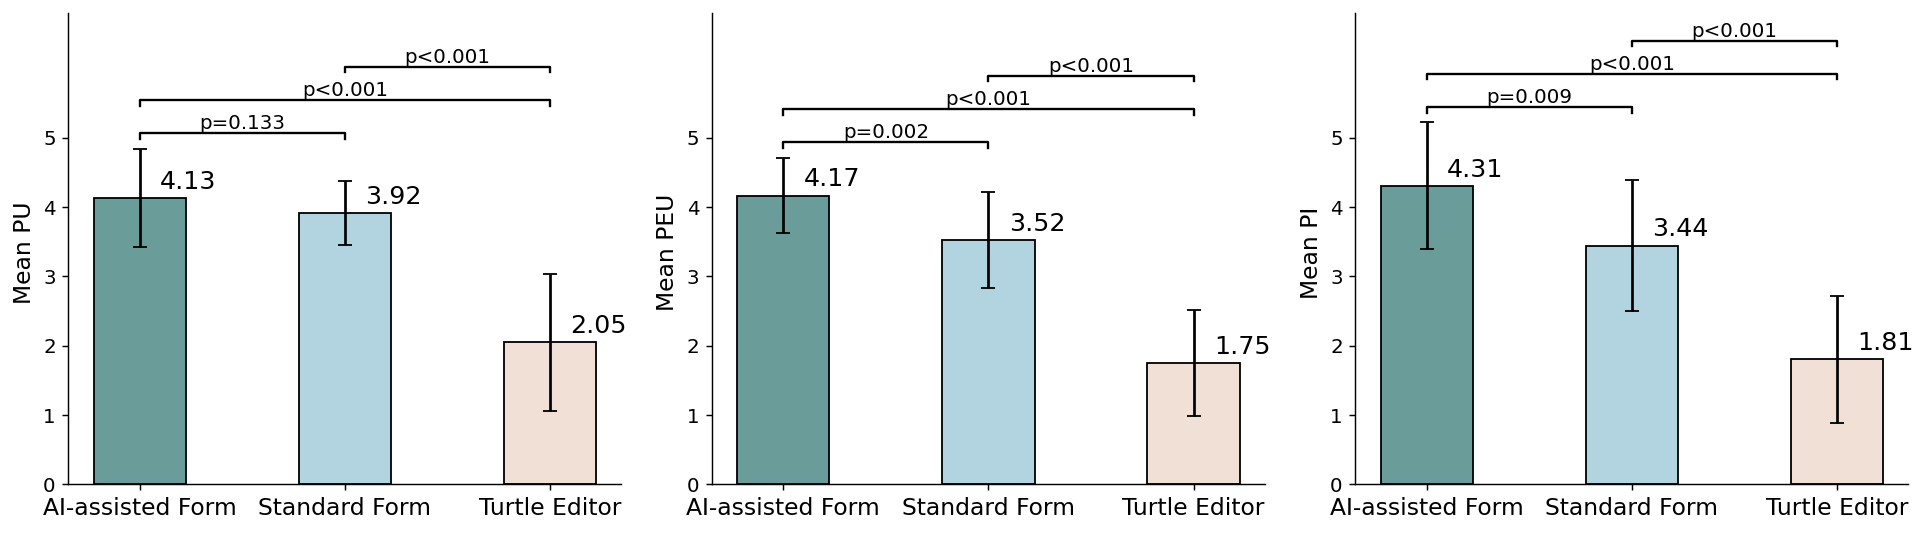

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Helper functions
# -----------------------------
def add_sig_bracket(ax, x1, x2, y, h, text, fontsize=11):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.3, c="black")
    ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom", fontsize=fontsize)

def get_p(posthoc_df, metric, A, B):
    sub = posthoc_df[posthoc_df["Metric"] == metric]
    row = sub[((sub["A"] == A) & (sub["B"] == B)) |
              ((sub["A"] == B) & (sub["B"] == A))]
    if row.empty:
        return None
    return float(row.iloc[0]["p-corr"])

def fmt_p(p):
    if p is None:
        return "p=?"
    return "p<0.001" if p < 0.001 else f"p={p:.3f}"

def plot_metric(ax, summary, posthoc_df, metric, ylabel, tool_colors):
    tools = list(summary.index)
    means = summary[(metric, "mean")].reindex(tools)
    errors = summary[(metric, "std")].reindex(tools)

    x = np.arange(len(tools))

    bars = ax.bar(
        x, means.values,
        yerr=errors.values,
        capsize=4,
        width=0.45,
        color=tool_colors,
        edgecolor="black"
    )

    # Axis labels and ticks
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(tools, rotation=0, fontsize=13)
    ax.tick_params(axis='y', labelsize=11)

    # Keep tick labels only to 5, but leave headroom for p-value brackets
    ax.set_ylim(0, 6.8)
    ax.set_yticks(np.arange(0, 5.1, 1))

    # Value labels: move slightly to the right of the error bar
    for bar in bars:
        h = bar.get_height()
        x_text = bar.get_x() + bar.get_width() / 2 + 0.10
        y_text = h + 0.06
        ax.text(
            x_text,
            y_text,
            f"{h:.2f}",
            ha="left",
            va="bottom",
            fontsize=14
        )

    # Add p-value brackets
    pairs = [
        ("AI-assisted Form", "Standard Form"),
        ("AI-assisted Form", "Turtle Editor"),
        ("Standard Form", "Turtle Editor"),
    ]

    tool_to_x = {t: i for i, t in enumerate(tools)}

    y_base = float((means + errors).max()) + 0.14
    step = 0.48

    for i, (A, B) in enumerate(pairs):
        p = get_p(posthoc_df, metric, A, B)
        if p is None:
            continue

        x1, x2 = tool_to_x[A], tool_to_x[B]

        add_sig_bracket(
            ax,
            x1,
            x2,
            y=y_base + i * step,
            h=0.08,
            text=fmt_p(p),
            fontsize=11
        )

# -----------------------------
# Plot all three metrics in one figure
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

plot_metric(axes[0], summary, posthoc_df, "PU",  "Mean PU ",  tool_colors)
plot_metric(axes[1], summary, posthoc_df, "PEU", "Mean PEU ", tool_colors)
plot_metric(axes[2], summary, posthoc_df, "PI",  "Mean PI ",  tool_colors)

plt.tight_layout()
plt.savefig("PU_PEU_PI_with_pbars.png", dpi=300, bbox_inches="tight")
plt.show()

# Qualitative Feedback Analysis

In [19]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

# ---------------------------------------
# 1. Load your dataset
# ---------------------------------------
df = pd.read_excel("Integrated_Responses.xlsx")   # <-- replace with your file


# ---------------------------------------
# 2. Stopwords
# ---------------------------------------
nltk.download('stopwords')
stop = set(stopwords.words("english"))
extra_stop = {"tool", "using", "use", "would", "could"}  # you can add more
stop |= extra_stop


# ---------------------------------------
# 3. Find relevant columns (robust detection)
# ---------------------------------------
def find_cols(keyword):
    return [
        c for c in df.columns
        if keyword.lower() in c.lower().replace("\xa0", " ").replace("\n", " ")
    ]

like_cols     = find_cols("what did you like most about this tool")
diff_cols     = find_cols("what difficulties did you experience while using this tool")
improve_cols  = find_cols("how could this tool")
feedback_cols = find_cols("please share any feedback")


# Map column lists to tool names
tools = {
    "LLM": {},
    "Form": {},
    "Turtle": {}
}

for col in like_cols:
    if "llm" in col.lower(): tools["LLM"]["liked"] = col
    elif "form interface" in col.lower(): tools["Form"]["liked"] = col
    elif "turtle" in col.lower(): tools["Turtle"]["liked"] = col

for col in diff_cols:
    if "llm" in col.lower(): tools["LLM"]["difficulties"] = col
    elif "form interface" in col.lower(): tools["Form"]["difficulties"] = col
    elif "turtle" in col.lower(): tools["Turtle"]["difficulties"] = col

for col in improve_cols:
    if "llm" in col.lower(): tools["LLM"]["improvements"] = col
    elif "form interface" in col.lower(): tools["Form"]["improvements"] = col
    elif "turtle" in col.lower(): tools["Turtle"]["improvements"] = col

for col in feedback_cols:
    if "llm" in col.lower(): tools["LLM"]["feedback"] = col
    elif "form interface" in col.lower(): tools["Form"]["feedback"] = col
    elif "turtle" in col.lower(): tools["Turtle"]["feedback"] = col


# ---------------------------------------
# 4. Clean text
# ---------------------------------------
def clean_text(t):
    t = str(t).lower()
    t = re.sub(r"[^a-zA-Z\s]", "", t)
    return t.strip()


# ---------------------------------------
# 5. Word frequency ignoring stopwords
# ---------------------------------------
def word_freq(texts, top_n=15):
    words = []
    for t in texts:
        for w in clean_text(t).split():
            if w not in stop and len(w) > 3:
                words.append(w)
    return Counter(words).most_common(top_n)


# ---------------------------------------
# 6. Process each tool
# ---------------------------------------
for tool, cols in tools.items():
    print("\n==========================")
    print(f"    {tool.upper()}")
    print("==========================")

    # Extract responses
    data = {
        part: df[cols[part]].dropna().astype(str).tolist()
        for part in ["liked", "difficulties", "improvements", "feedback"]
        if part in cols
    }

    # Save to CSV
    out_df = pd.DataFrame.from_dict(data, orient='index').transpose()
    out_path = f"{tool}_analysis.csv"
    out_df.to_csv(out_path, index=False)
    print(f"Saved CSV: {out_path}")

    # Combine all text for word frequencies
    all_text = []
    for part in ["liked", "difficulties", "improvements", "feedback"]:
        if part in data:
            all_text.extend(data[part])

    # If no data, skip
    if not all_text:
        continue

    # Get frequencies
    freq = word_freq(all_text)

    # Plot (allowed: simple matplotlib bar chart)
    if len(freq) > 0:
        words, counts = zip(*freq)
        plt.figure(figsize=(8, 5))
        plt.bar(words, counts)   # no colors manually set
        plt.xticks(rotation=45, ha='right')
        plt.title(f"Top Words for {tool}")
        plt.tight_layout()
        plt.savefig(f"{tool}_wordfreq.png")
        plt.close()
        print(f"Saved plot: {tool}_wordfreq.png")


[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.



    LLM
Saved CSV: LLM_analysis.csv
Saved plot: LLM_wordfreq.png

    FORM
Saved CSV: Form_analysis.csv
Saved plot: Form_wordfreq.png

    TURTLE
Saved CSV: Turtle_analysis.csv
Saved plot: Turtle_wordfreq.png


# Evaluation of Submitted Metadata

In [ ]:
import json, re
from pathlib import Path
from collections import defaultdict
import pandas as pd
import numpy as np

from fuzzywuzzy import fuzz
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rouge_score import rouge_scorer

# ----------------------------------------------
# CONFIG
# ----------------------------------------------

DATA_ROOT = Path("Usability_Study_29_Oct")
GT_ROOT   = Path(".")

VALID_DATASETS = {"yago", "bio2rdf", "quotekg"}
EMPTY_STRINGS = {"", "n/a", "na", "null", "none", "undefined"}
KEY_RENAMES = {"void:description": "foaf:depiction"}
SIM_THRESHOLD = 0.7

metric_map = {
    "exact": [
        "dct:title","dct:created","dct:modified","dct:issued","dcat:version","dcat:acronym",
        "dct:accessrights","void:triple","dct:license","dct:conformsto",
        "void:urispace","void:uriregexpattern","void:sparqlendpoint","rdfs:seealso",
        "dct:references","dcat:landingpage","dcat:servesdataset","cito:citesasauthority",
        "void:vocabulary","dct:alternative","foaf:depiction","void:linkset",
        "mod:sampleQueries","dct:language"
    ],
    "rouge": ["dct:description"],
    "cosine": ["dcat:keyword","dcat:theme"],
    "fuzzy": ["prov:qualifiedattribution"],
}

subelement_metric_map = {
    ("prov:qualifiedattribution","email"): "exact",
    ("prov:qualifiedattribution","givenname"): "fuzzy",
    ("prov:qualifiedattribution","roletype"): "exact",

    ("dcat:distribution","accessurl"): "exact",
    ("dcat:distribution","title"): "exact",
    ("dcat:distribution","description"): "rouge",

    ("void:exampleresource","dct:title"): "exact",
    ("void:exampleresource","dct:description"): "rouge",
    ("void:exampleresource","dcat:accessurl"): "exact",

    ("void:sparqlendpoint","dct:title"): "exact",
    ("void:sparqlendpoint","dct:description"): "rouge",
    ("void:sparqlendpoint","adms:status"): "exact",
    ("void:sparqlendpoint","void:sparqlendpoint"): "exact",

    ("void:linkset","target"): "exact",
    ("void:linkset","triples"): "exact",
}

ALLOWED_PROV_SUBKEYS = {"roletype","givenname","email"}

# ----------------------------------------------
# LOAD GROUND TRUTHS
# ----------------------------------------------

def load_ground_truths():
    out = {}
    for ds in VALID_DATASETS:
        p = GT_ROOT / f"Ground_truth_{ds}.json"
        raw = json.loads(p.read_text(encoding="utf-8"))
        gt = raw.get("formData", raw)

        fixed = {}
        for k, v in gt.items():
            k2 = KEY_RENAMES.get(k.lower(), k.lower())
            fixed[k2] = v
        out[ds] = fixed
    return out

GROUND_TRUTHS = load_ground_truths()

# ----------------------------------------------
# SIMILARITY FUNCTIONS
# ----------------------------------------------

def rouge1(a, b):
    scorer = rouge_scorer.RougeScorer(["rouge1"], use_stemmer=True)
    return scorer.score(str(a), str(b))["rouge1"].fmeasure

def cosine_text(a, b):
    a, b = str(a), str(b)
    if not a.strip() and not b.strip():
        return 1.0
    if not a.strip() or not b.strip():
        return 0.0
    vect = TfidfVectorizer().fit([a, b])
    tfidf = vect.transform([a, b])
    return float(cosine_similarity(tfidf[0], tfidf[1]))

def fuzzy_sim(a, b):
    return fuzz.ratio(str(a).lower(), str(b).lower()) / 100.0

def exact_sim(a, b):
    return 1.0 if str(a).strip().lower() == str(b).strip().lower() else 0.0

# ----------------------------------------------
# FILTERS + NORMALIZATION
# ----------------------------------------------

def filter_prov(v):
    if isinstance(v, dict):
        return {k: v2 for k, v2 in v.items() if k.lower() in ALLOWED_PROV_SUBKEYS}
    if isinstance(v, list):
        return [
            {k: v2 for k, v2 in item.items() if k.lower() in ALLOWED_PROV_SUBKEYS}
            if isinstance(item, dict) else item
            for item in v
        ]
    return v

# ----------------------------------------------
# DEEP FLATTENING (ORDER-INVARIANT)
# ----------------------------------------------

def flatten_atoms(root_key, value):
    atoms = []
    rk = root_key.lower()

    def rec(v, path):
        if v is None:
            return
        if isinstance(v, (str, int, float, bool)):
            leaf = str(v).strip().lower()
            if leaf not in EMPTY_STRINGS:
                atoms.append((tuple(path), leaf))
        elif isinstance(v, list):
            for item in v:
                rec(item, path)  # no index => order-invariant
        elif isinstance(v, dict):
            for k, val in v.items():
                rec(val, path + [k.lower()])
        else:
            leaf = str(v).strip().lower()
            if leaf not in EMPTY_STRINGS:
                atoms.append((tuple(path), leaf))

    rec(value, [rk])
    return atoms

# ----------------------------------------------
# METRIC SELECTION
# ----------------------------------------------

def get_metric_name(root, sub):
    rk, sk = root.lower(), sub.lower()
    if (rk, sk) in subelement_metric_map:
        return subelement_metric_map[(rk, sk)]
    if rk == "dct:creator":
        return "fuzzy"
    for metric, keys in metric_map.items():
        if rk in [k.lower() for k in keys]:
            return metric
    return "exact"

def apply_metric(metric, u, g):
    if metric == "exact":
        return exact_sim(u, g)
    if metric == "rouge":
        return rouge1(u, g)
    if metric == "cosine":
        return cosine_text(u, g)
    if metric == "fuzzy":
        return fuzzy_sim(u, g)
    return exact_sim(u, g)

# ----------------------------------------------
# ONE-TO-ONE MATCHING PER PATH (ORDER-INVARIANT)
# ----------------------------------------------

def one_to_one_best_scores(metric, user_values, gt_values):
    """
    Returns a one-to-one alignment between unordered user values and unordered
    ground-truth values for a single field path.
    Greedy maximum-weight matching is sufficient here because per-path lists are tiny.
    """
    if not user_values and not gt_values:
        return [], [], []

    pairs = []
    for ui, u in enumerate(user_values):
        for gi, g in enumerate(gt_values):
            sim = apply_metric(metric, u, g)
            pairs.append((sim, ui, gi))

    pairs.sort(reverse=True, key=lambda x: x[0])

    used_u = set()
    used_g = set()
    matches = []

    for sim, ui, gi in pairs:
        if ui in used_u or gi in used_g:
            continue
        used_u.add(ui)
        used_g.add(gi)
        matches.append((ui, gi, sim))

    user_best = [0.0] * len(user_values)
    gt_best = [0.0] * len(gt_values)
    for ui, gi, sim in matches:
        user_best[ui] = sim
        gt_best[gi] = sim

    return matches, user_best, gt_best

def one_to_one_field_alignment(root_key, user_atoms, gt_atoms):
    """
    Performs one-to-one matching separately inside each atomic path.
    Returns:
      - gt_avg_score: average best score over GT atoms (for recall-style field scoring)
      - user_avg_score: average best score over user atoms (for precision-style scoring)
      - per_atom_scores: best score for each user atom in original order
      - used_metrics: metrics used in this field
    """
    rk = root_key.lower()

    user_by_path = defaultdict(list)
    gt_by_path = defaultdict(list)

    for idx, (p, u) in enumerate(user_atoms):
        user_by_path[p].append((idx, u))
    for p, g in gt_atoms:
        gt_by_path[p].append(g)

    all_paths = sorted(set(user_by_path.keys()) | set(gt_by_path.keys()))
    used_metrics = set()

    per_atom_scores = [0.0] * len(user_atoms)
    gt_scores_all = []

    for path in all_paths:
        user_items = user_by_path.get(path, [])
        gt_values = gt_by_path.get(path, [])

        sub = path[-1] if len(path) > 1 else path[0]
        metric = get_metric_name(rk, sub)
        used_metrics.add(metric)

        user_indices = [idx for idx, _ in user_items]
        user_values = [u for _, u in user_items]

        _, user_best, gt_best = one_to_one_best_scores(metric, user_values, gt_values)

        for local_i, global_i in enumerate(user_indices):
            per_atom_scores[global_i] = user_best[local_i]
        gt_scores_all.extend(gt_best)

    gt_avg_score = (sum(gt_scores_all) / len(gt_scores_all)) if gt_scores_all else (1.0 if not user_atoms else 0.0)
    user_avg_score = (sum(per_atom_scores) / len(per_atom_scores)) if per_atom_scores else np.nan

    return gt_avg_score, user_avg_score, per_atom_scores, used_metrics

# ----------------------------------------------
# MAIN LOOP
# ----------------------------------------------

def compute_gt_total_atoms(gt_form):
    total = 0
    for key_l, gt_val in gt_form.items():
        root_key = key_l.lower()
        if root_key == "prov:qualifiedattribution":
            gt_val = filter_prov(gt_val)
        total += len(flatten_atoms(root_key, gt_val))
    return total

detail_rows = []
file_rows = []

for fp in DATA_ROOT.rglob("*.json"):
    if "checkpoint" in fp.name.lower():
        continue

    try:
        data_text = fp.read_text(encoding="utf-8")
        data = json.loads(data_text)
    except Exception:
        continue

    m = re.search(r'"name"\s*:\s*"([^"]+)"', data_text, flags=re.I)
    dataset = m.group(1).strip().lower() if m else ""
    if dataset not in VALID_DATASETS:
        continue

    gt_form = GROUND_TRUTHS[dataset]
    gt_total_atoms = compute_gt_total_atoms(gt_form)
    form_raw = data.get("formData", {}) or {}

    form = {}
    for k, v in form_raw.items():
        k2 = KEY_RENAMES.get(k.lower(), k.lower())
        form[k2] = v

    participant = fp.parent.parent.name
    submission = data.get("metadata", {}).get("submissionType", "unknown")
    duration = data.get("metadata", {}).get("totalTimeSpentSeconds")

    main_nonempty = 0
    total_user_values = 0
    total_correct_values = 0
    field_sims_gt = []
    field_sims_user = []

    for key_l, gt_val in gt_form.items():
        root_key = key_l.lower()
        user_val = form.get(root_key, None)

        if root_key == "prov:qualifiedattribution":
            gt_val = filter_prov(gt_val)
            user_val = filter_prov(user_val)

        gt_atoms = flatten_atoms(root_key, gt_val)
        user_atoms = flatten_atoms(root_key, user_val) if user_val not in (None, "", [], {}) else []

        if user_atoms:
            main_nonempty += 1
            total_user_values += len(user_atoms)

        sim_gt, sim_user, per_atom_scores, used_metrics = one_to_one_field_alignment(root_key, user_atoms, gt_atoms)
        correct_atoms = sum(score >= SIM_THRESHOLD for score in per_atom_scores)
        total_correct_values += correct_atoms

        field_sims_gt.append(sim_gt)
        if not np.isnan(sim_user):
            field_sims_user.append(sim_user)

        detail_rows.append({
            "participant_id": participant,
            "submissionType": submission,
            "dataset": dataset,
            "key": root_key,
            "matching_mode": ", ".join(sorted(used_metrics)),
            "similarity_score": round(sim_gt, 4),
            "similarity_user": "" if np.isnan(sim_user) else round(sim_user, 4),
            "user_values_count": len(user_atoms),
            "gt_values_count": len(gt_atoms),
            "correct_atom_count": correct_atoms,
            "ground_truth_value": json.dumps(gt_val, ensure_ascii=False),
            "user_value": json.dumps(user_val, ensure_ascii=False),
            "file_path": str(fp)
        })

    avg_sim_gt = sum(field_sims_gt) / len(field_sims_gt) if field_sims_gt else np.nan
    avg_sim_user = sum(field_sims_user) / len(field_sims_user) if field_sims_user else np.nan

    completeness_ratio = (total_user_values / gt_total_atoms) if gt_total_atoms > 0 else np.nan
    precision_ratio = (total_correct_values / total_user_values) if total_user_values > 0 else np.nan
    recall_ratio = (total_correct_values / gt_total_atoms) if gt_total_atoms > 0 else np.nan
    f1_ratio = (
        2 * precision_ratio * recall_ratio / (precision_ratio + recall_ratio)
        if pd.notna(precision_ratio) and pd.notna(recall_ratio) and (precision_ratio + recall_ratio) > 0
        else np.nan
    )
    values_per_min = (
        (total_user_values / duration) * 60.0
        if duration not in (None, 0) and pd.notna(duration) and total_user_values > 0
        else np.nan
    )

    file_rows.append({
        "participant_id": participant,
        "submissionType": submission,
        "dataset": dataset,
        "durationSeconds": duration,
        "gt_total_atoms": gt_total_atoms,
        "main_fields_nonempty": main_nonempty,
        "total_user_values": total_user_values,
        "total_correct_values": total_correct_values,
        "avg_similarity": round(avg_sim_gt, 4) if pd.notna(avg_sim_gt) else np.nan,
        "avg_similarity_user": round(avg_sim_user, 4) if pd.notna(avg_sim_user) else np.nan,
        "completeness_ratio": completeness_ratio,
        "precision_ratio": precision_ratio,
        "recall_ratio": recall_ratio,
        "f1_ratio": f1_ratio,
        "values_per_min": values_per_min,
        "file_path": str(fp),
    })

# ----------------------------------------------
# SAVE OUTPUT
# ----------------------------------------------

out = Path("Evaluation_Reports_invarient_one2one")
out.mkdir(exist_ok=True)

detail_df = pd.DataFrame(detail_rows)
summary_df = pd.DataFrame(file_rows)

for ds in sorted(detail_df["dataset"].dropna().unique()):
    detail_df[detail_df["dataset"] == ds].to_csv(
        out / f"{ds}_per_element_per_participant.csv", index=False
    )

summary_df.to_csv(out / "Per_File_Summary.csv", index=False)

if not summary_df.empty:
    tool_avg = (
        summary_df.groupby(["dataset", "submissionType"], as_index=False)[
            ["completeness_ratio", "precision_ratio", "recall_ratio", "f1_ratio", "values_per_min"]
        ]
        .mean()
    )
    tool_avg.to_csv(out / "Dataset_Tool_Averages.csv", index=False)

print("✔ DONE — corrected evaluation files written successfully.")



Balanced participants used (n=9): ['P1', 'P10', 'P11', 'P12', 'P3', 'P5', 'P6', 'P8', 'P9']


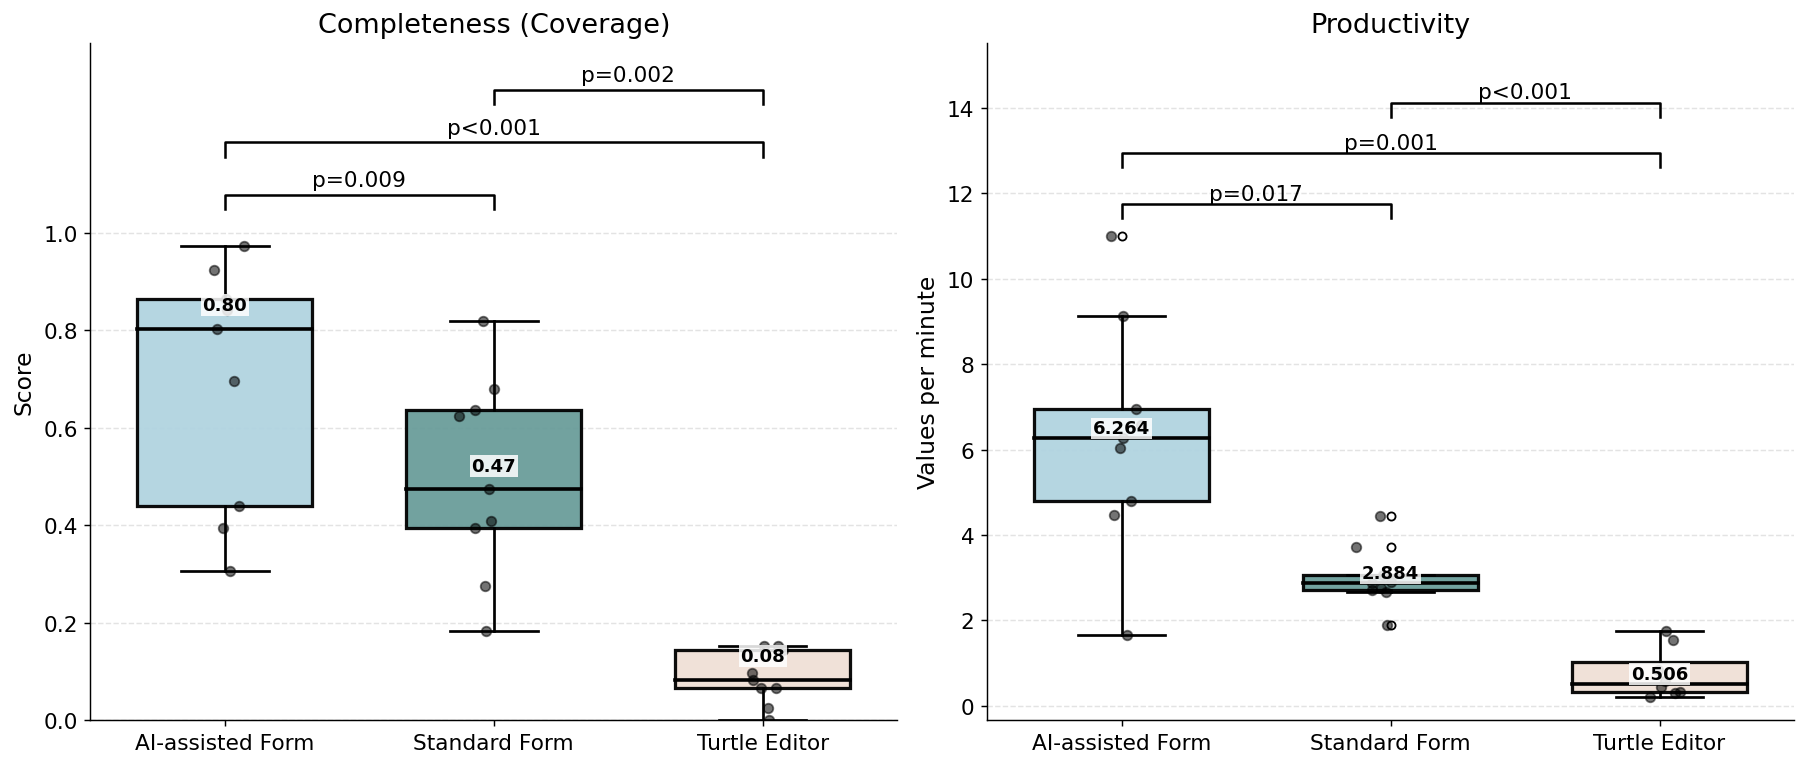

Saved: COVERAGE_EFFICIENCY_WITH_PVALUES.png


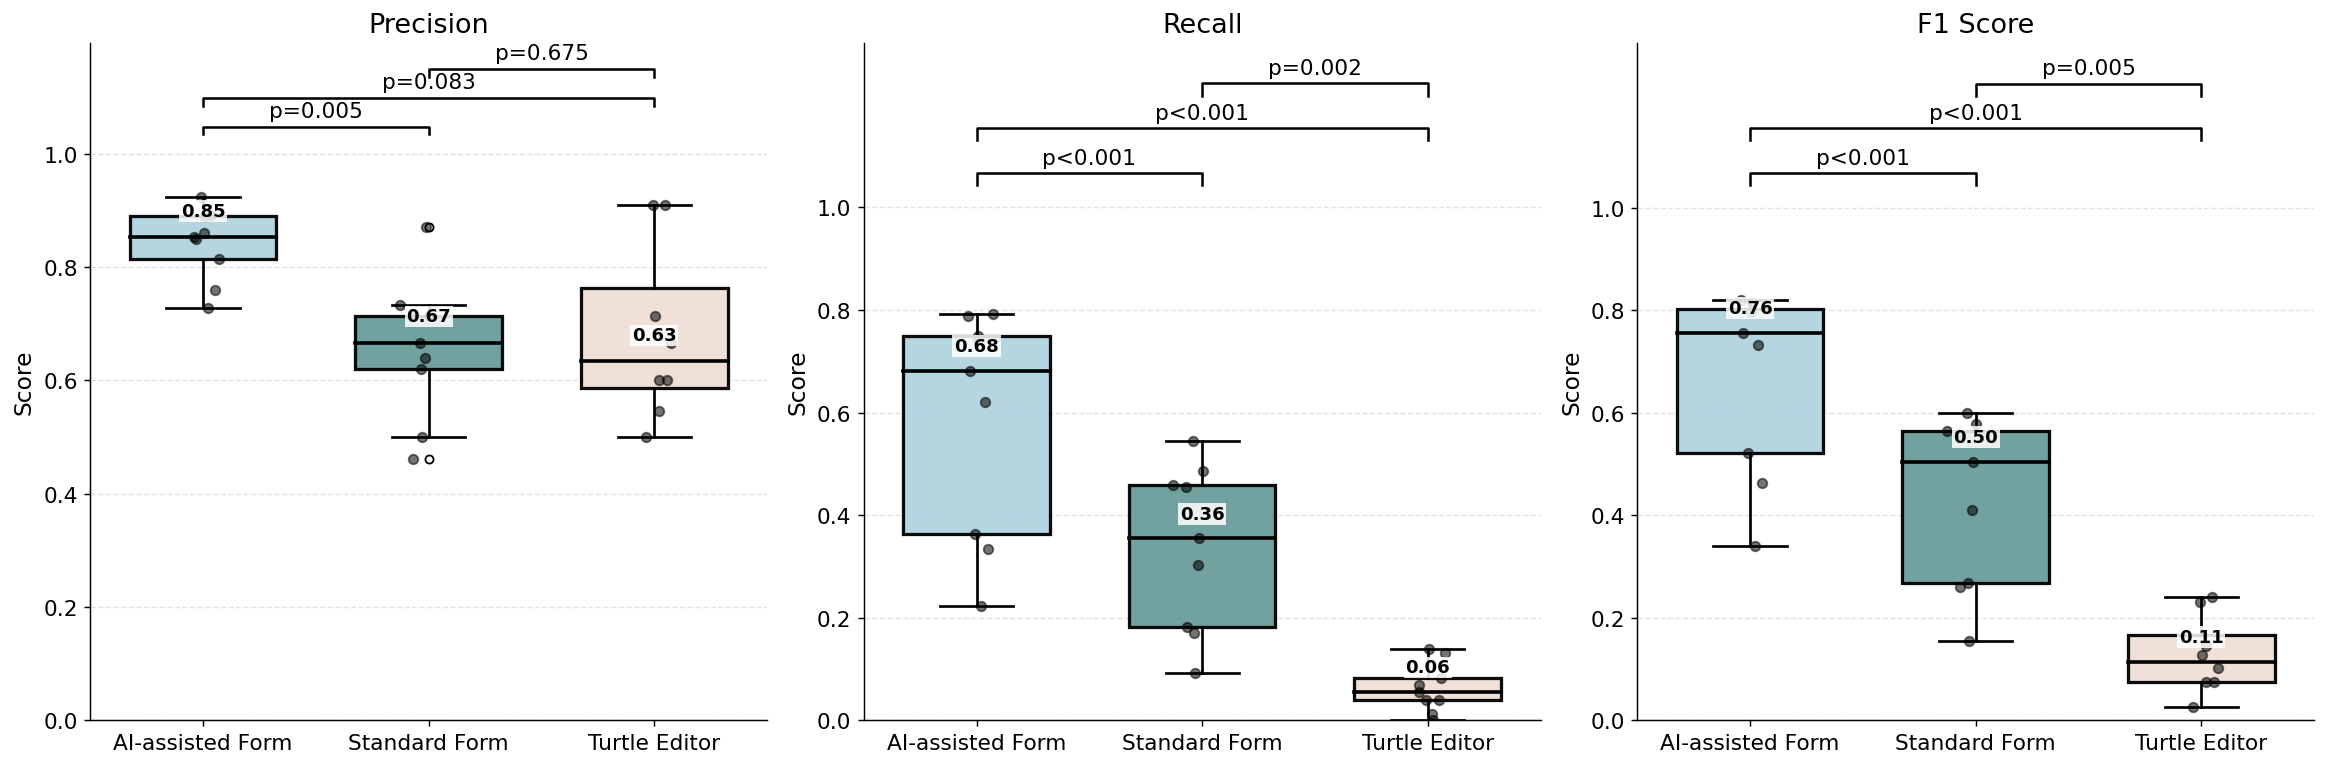

Saved: PRECISION_RECALL_F1_WITH_PVALUES.png


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg

# ==========================================================
# CONFIG
# ==========================================================
csv_path = "Evaluation_Reports_invarient_one2one/Per_File_Summary.csv"

label_map = {
    "regular": "Standard Form",
    "llm": "AI-assisted Form",
    "turtle editor": "Turtle Editor"
}
type_order = ["AI-assisted Form", "Standard Form", "Turtle Editor"]

color_map = {
    "Standard Form": "#6a9d9a",
    "AI-assisted Form": "#b1d4e0",
    "Turtle Editor": "#f0e0d6"
}

plt.rcParams.update({
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# ==========================================================
# LOAD + CLEAN
# ==========================================================
df = pd.read_csv(csv_path)
df["submissionType"] = df["submissionType"].astype(str).str.lower().map(label_map)
df = df[df["submissionType"].notna()].copy()

def normalize_pid(pid):
    pid = str(pid).strip().upper()
    if pid.startswith("P"):
        try:
            return "P" + str(int(pid[1:]))  # P01 -> P1
        except Exception:
            return pid
    return pid

df["participant_norm"] = df["participant_id"].apply(normalize_pid)

# GT atom count
df["gt_size"] = pd.to_numeric(df["gt_total_atoms"], errors="coerce")

if df["gt_size"].isna().any():
    raise ValueError("Some rows have missing or invalid values in 'gt_total_atoms'.")

# ==========================================================
# METRICS (per-file)
# ==========================================================
# Coverage (completeness / attempted)
df["coverage_ratio"] = df["total_user_values"] / df["gt_size"]

# Precision = correct / entered
df["precision_ratio"] = np.where(
    df["total_user_values"] > 0,
    df["total_correct_values"] / df["total_user_values"],
    np.nan
)

# Recall = correct / ground-truth
df["recall_ratio"] = df["total_correct_values"] / df["gt_size"]

# F1
df["f1_ratio"] = np.where(
    (df["precision_ratio"].notna()) & (df["recall_ratio"].notna()) & ((df["precision_ratio"] + df["recall_ratio"]) > 0),
    2 * (df["precision_ratio"] * df["recall_ratio"]) / (df["precision_ratio"] + df["recall_ratio"]),
    np.nan
)

# Efficiency = values per minute
df["values_per_min"] = np.where(
    (df["durationSeconds"].notna()) & (df["durationSeconds"] > 0) & (df["total_user_values"] > 0),
    (df["total_user_values"] / df["durationSeconds"]) * 60.0,
    np.nan
)

# ==========================================================
# Aggregate to PARTICIPANT × TOOL (within-subject)
# ==========================================================
metrics_cols = ["coverage_ratio", "precision_ratio", "recall_ratio", "f1_ratio", "values_per_min"]

pt = (
    df.groupby(["participant_norm", "submissionType"], as_index=False)[metrics_cols]
      .mean()
)

# Keep only participants who have ALL tools
counts = pt.groupby("participant_norm")["submissionType"].nunique()
keep_p = counts[counts == len(type_order)].index
pt = pt[pt["participant_norm"].isin(keep_p)].copy()

print(f"\nBalanced participants used (n={pt['participant_norm'].nunique()}): {sorted(pt['participant_norm'].unique())}")

# ==========================================================
# STATS: Pairwise comparisons (PAIRED) with Holm correction
# ==========================================================
def pairwise_tool_tests(metric_col):
    ph = pg.pairwise_tests(
        data=pt,
        dv=metric_col,
        within="submissionType",
        subject="participant_norm",
        padjust="holm",
        effsize="cohen"
    )
    return ph[["A", "B", "p-corr"]].copy()

posthoc = {m: pairwise_tool_tests(m) for m in metrics_cols}

# ==========================================================
# Helpers
# ==========================================================
positions = [1, 2, 3]

def data_by_tool(metric_col):
    return [pt.loc[pt["submissionType"] == t, metric_col].dropna().values for t in type_order]

def color_boxes(bp, order):
    for box, t in zip(bp["boxes"], order):
        box.set_facecolor(color_map[t])
        box.set_edgecolor("black")
        box.set_alpha(0.95)

def overlay_points(ax, data, positions, jitter=0.05, alpha=0.55, size=28):
    rng = np.random.default_rng(0)  # deterministic jitter
    for x0, vals in zip(positions, data):
        vals = np.asarray(vals, dtype=float)
        vals = vals[~np.isnan(vals)]
        if len(vals) == 0:
            continue
        xs = rng.normal(x0, jitter, size=len(vals))
        ax.scatter(xs, vals, color="black", alpha=alpha, s=size, zorder=3)

def annotate_medians(ax, data, positions, fmt="{:.2f}", y_offset=0.03):
    for x0, vals in zip(positions, data):
        arr = np.asarray(vals, dtype=float)
        arr = arr[~np.isnan(arr)]
        if len(arr) == 0:
            continue
        md = float(np.median(arr))
        ax.text(
            x0, md + y_offset, fmt.format(md),
            ha="center", va="bottom",
            fontsize=10, fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.0),
            zorder=5
        )

def fmt_p_value(p):
    if pd.isna(p):
        return "p=?"
    if p < 0.001:
        return "p<0.001"
    return f"p={p:.3f}"

def get_pair_p(metric_col, A, B):
    ph = posthoc[metric_col]
    row = ph[((ph["A"] == A) & (ph["B"] == B)) | ((ph["A"] == B) & (ph["B"] == A))]
    if row.empty:
        return np.nan
    return float(row.iloc[0]["p-corr"])

def add_sig_bracket(ax, x1, x2, y, h, text, lw=1.4, fs=12):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=lw, c="black", clip_on=False)
    ax.text((x1 + x2) / 2, y + h + 0.01, text, ha="center", va="bottom", fontsize=fs)

def add_all_pairwise_brackets(ax, metric_col, data, ylim=None):
    pairs = [
        (1, 2, "AI-assisted Form", "Standard Form"),
        (1, 3, "AI-assisted Form", "Turtle Editor"),
        (2, 3, "Standard Form", "Turtle Editor"),
    ]
    all_vals = np.concatenate([np.asarray(d, dtype=float) for d in data if len(d) > 0])
    all_vals = all_vals[~np.isnan(all_vals)]
    if len(all_vals) == 0:
        return

    y_min = float(np.nanmin(all_vals))
    y_max = float(np.nanmax(all_vals))
    data_range = max(y_max - y_min, 1e-6)

    if ylim is not None:
        base_y = ylim[1] + data_range * 0.03
        h = data_range * 0.03
        step = data_range * 0.11
        ax.set_ylim(ylim[0], ylim[1] + data_range * 0.38)
    else:
        base_y = y_max + data_range * 0.04
        h = data_range * 0.03
        step = data_range * 0.11
        ax.set_ylim(y_min - data_range * 0.05, y_max + data_range * 0.42)

    for i, (x1, x2, A, B) in enumerate(pairs):
        p = get_pair_p(metric_col, A, B)
        add_sig_bracket(ax, x1, x2, base_y + i * step, h, fmt_p_value(p))

def draw_metric_boxplot(ax, title, metric_col, ylim, ylabel, med_fmt="{:.2f}", yoff=0.03):
    data = data_by_tool(metric_col)
    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.65,
        patch_artist=True,
        boxprops=dict(linewidth=1.8),
        medianprops=dict(linewidth=2, color="black"),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker="o", markersize=4.5, markerfacecolor="white", markeredgecolor="black")
    )
    color_boxes(bp, type_order)
    overlay_points(ax, data, positions, jitter=0.055, alpha=0.55, size=28)
    annotate_medians(ax, data, positions, fmt=med_fmt, y_offset=yoff)

    ax.set_title(title)
    ax.set_xticks(positions)
    ax.set_xticklabels(type_order, rotation=0, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.grid(axis="y", linestyle="--", alpha=0.35)

    if ylim is not None:
        ax.set_ylim(ylim[0], ylim[1] + 0.15)
        ax.set_yticks(np.arange(0, 1.1, 0.2))

    add_all_pairwise_brackets(ax, metric_col, data, ylim=ylim)

# ==========================================================
# FIGURE 1: Coverage + Efficiency (1x2)
# ==========================================================
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 6))

draw_metric_boxplot(
    axes1[0],
    "Completeness (Coverage)",
    "coverage_ratio",
    (0, 1.02),
    "Score",
    med_fmt="{:.2f}",
    yoff=0.03
)

draw_metric_boxplot(
    axes1[1],
    "Productivity",
    "values_per_min",
    None,
    "Values per minute",
    med_fmt="{:.3f}",
    yoff=0.02
)

plt.tight_layout()
plt.savefig("COVERAGE_EFFICIENCY_WITH_PVALUES.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: COVERAGE_EFFICIENCY_WITH_PVALUES.png")

# ==========================================================
# FIGURE 2: Precision + Recall + F1 (1x3)
# ==========================================================
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6))

draw_metric_boxplot(
    axes2[0],
    "Precision",
    "precision_ratio",
    (0, 1.02),
    "Score",
    med_fmt="{:.2f}",
    yoff=0.03
)

draw_metric_boxplot(
    axes2[1],
    "Recall",
    "recall_ratio",
    (0, 1.02),
    "Score",
    med_fmt="{:.2f}",
    yoff=0.03
)

draw_metric_boxplot(
    axes2[2],
    "F1 Score",
    "f1_ratio",
    (0, 1.02),
    "Score",
    med_fmt="{:.2f}",
    yoff=0.03
)

plt.tight_layout()
plt.savefig("PRECISION_RECALL_F1_WITH_PVALUES.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: PRECISION_RECALL_F1_WITH_PVALUES.png")